# Load and Plot SWOT EXPERT Data

Authors: Lexi Jones-Kellett, Sarah Lang, Tasha Snow

- Showing the SWOT data compared to OSCAR
- Calculated SWOT velocities and streamlines from L2
- Visualize eddy contour detected by AVISO eddy tracking

Note: Please see two boxes that beging with "To do" below.

In [1]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

In [2]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

### To do: Below, add date requested in following formats. Input correct AVISO data for eddy of interest.

In [3]:
date_requested = '20240531'
pacedate="2024-05-31"

In [7]:
aviso_ds = xr.open_dataset('Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20241111_ID_164996.nc')

<xarray.Dataset> Size: 346kB
Dimensions:                        (obs: 382, NbSample: 20)
Dimensions without coordinates: obs, NbSample
Data variables: (12/27)
    amplitude                      (obs) float64 3kB ...
    effective_area                 (obs) float32 2kB ...
    effective_contour_height       (obs) float32 2kB ...
    effective_contour_latitude     (obs, NbSample) float64 61kB ...
    effective_contour_longitude    (obs, NbSample) float64 61kB ...
    effective_contour_shape_error  (obs) float64 3kB ...
    ...                             ...
    speed_contour_longitude        (obs, NbSample) float64 61kB ...
    speed_contour_shape_error      (obs) float64 3kB ...
    speed_radius                   (obs) float64 3kB ...
    time                           (obs) datetime64[ns] 3kB ...
    track                          (obs) uint32 2kB ...
    uavg_profile                   (obs, NbSample) float64 61kB ...
Attributes: (12/19)
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    creator_email:             aviso@altimetry.fr
    creator_url:               https://www.aviso.altimetry.fr
    date_created:              2025-02-03T08:39:10Z
    framework_used:            https://github.com/AntSimi/py-eddy-tracker
    ...                        ...
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    summary:                   This dataset contains eddy atlas from all-sate...
    time_coverage_duration:    P2507D
    time_coverage_end:         2024-11-11T00:00:00Z
    time_coverage_start:       2018-01-01T00:00:00Z
    title:                     Mesoscale Cyclonic Eddies in Altimeter Observa...

### To do: Add in low-res altimeter data (SSH)

NOTE: I can't find any usable SSH products in EarthAccess. Downloaded data from CMEMS here: https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_NRT_008_046/files?subdataset=cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_202311&path=SEALEVEL_GLO_PHY_L4_NRT_008_046%2Fcmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_202311%2F2024%2F05%2F

In [ ]:
CMEMS_dir = '../CMEMS_data/'
CMEMS_day = xr.open_dataset(CMEMS_dir + 'nrt_global_allsat_phy_l4_20240508_20240514.nc')
CMEMS_day

In [12]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-08-21T00:00:00.000000000
2024-09-05T00:00:00.000000000
382
35.816544
37.76855
-53.7723388671875
-43.41046142578125


Log into earthaccess

In [13]:
auth = earthaccess.login(persist=True)

Check the names of the SWOT datasets available on earthaccess

In [15]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [17]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 628


QUEUEING TASKS | :   0%|          | 0/628 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/628 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/628 [00:00<?, ?it/s]

Get all dates with SWOT swaths through the bounding box

In [18]:
dates_available = []
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if today not in dates_available:
        dates_available.append(today)
print(dates_available)

['20230821', '20230822', '20230823', '20230824', '20230825', '20230826', '20230830', '20230831', '20230901', '20230902', '20230903', '20230904', '20230905', '20230906', '20230909', '20230910', '20230911', '20230912', '20230913', '20230914', '20230915', '20230916', '20230919', '20230920', '20230921', '20230930', '20231001', '20231002', '20231003', '20231004', '20231005', '20231006', '20231010', '20231011', '20231012', '20231013', '20231014', '20231015', '20231016', '20231017', '20231021', '20231022', '20231023', '20231024', '20231025', '20231026', '20231027', '20231031', '20231101', '20231102', '20231103', '20231104', '20231105', '20231106', '20231107', '20231111', '20231112', '20231113', '20231114', '20231115', '20231116', '20231117', '20231121', '20231122', '20231123', '20231124', '20231125', '20231126', '20231127', '20231128', '20231201', '20231202', '20231203', '20231204', '20231205', '20231206', '20231207', '20231208', '20231212', '20231213', '20231214', '20231215', '20231216', '20

Get data from a specific date

NOTE: 2024/05/23 isn't cropping

In [19]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

493
494


There are 2 swaths on the date of interest

Open a single dataset.

NOTE: Will need to point to different indices if you change the bounding box

In [20]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [21]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [22]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

Need to add 'height_cor_xover' values to ssh & sla variabiles

<Figure size 640x480 with 0 Axes>

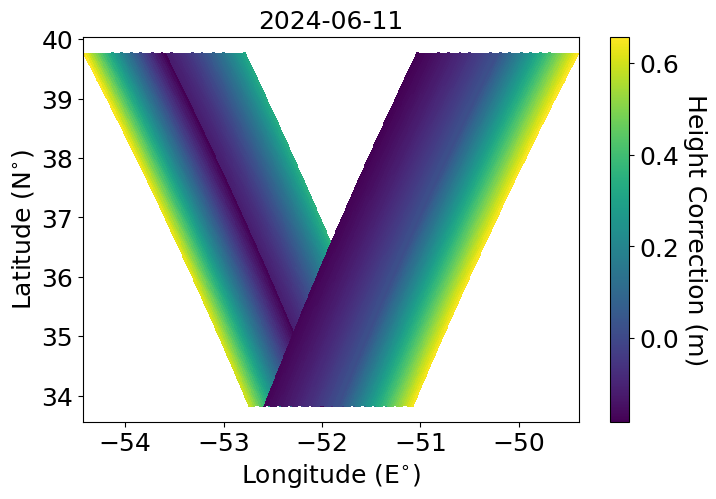

In [23]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,ds1_masked.height_cor_xover)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,ds2_masked.height_cor_xover)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('Height Correction (m)', rotation=270, labelpad=20)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

SSHA Karin 2 is the best quality to show the eddy

<Figure size 640x480 with 0 Axes>

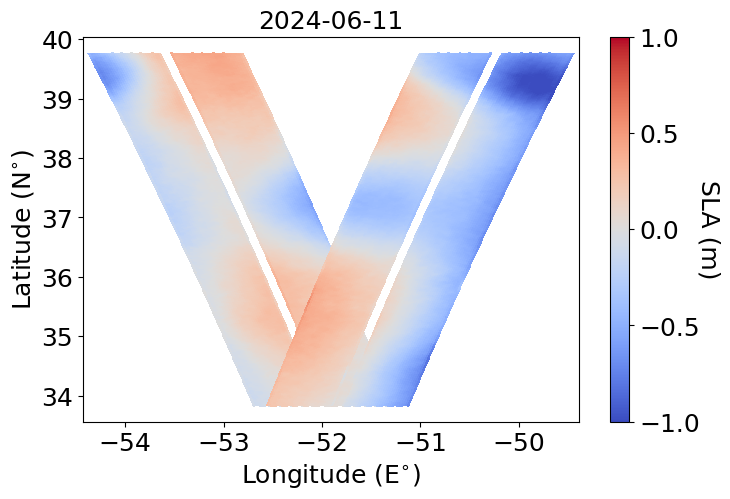

In [24]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,ds1_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,ds2_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)

#plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

Plot overlap

<Figure size 640x480 with 0 Axes>

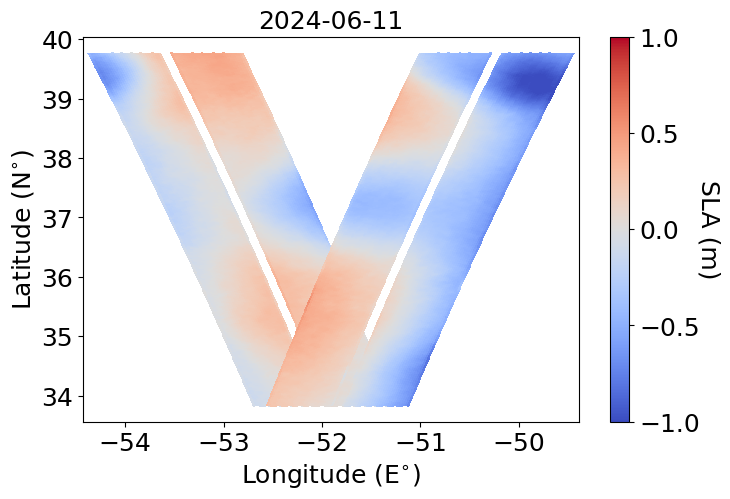

In [25]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,ds1_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,ds2_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)

#plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

Regrid SWOT data to regular grid. Need to do this before taking spatial gradients for velocity calculations.

In [26]:
xv = np.arange(lonmin+360, lonmax+360, 0.036)
yv = np.arange(latmin,latmax, 0.036)
grid_x, grid_y = np.meshgrid(xv, yv)
ssh=ds1_masked.ssha_karin_2+ds1_masked.height_cor_xover
lat=ds1_masked.latitude
lon=ds1_masked.longitude
grid_ssh1 = griddata((lon.values.ravel(),lat.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')
ssh=ds2_masked.ssha_karin_2+ds2_masked.height_cor_xover
lat=ds2_masked.latitude
lon=ds2_masked.longitude
grid_ssh2 = griddata((lon.values.ravel(),lat.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')

Plot regridded SSH

<Figure size 640x480 with 0 Axes>

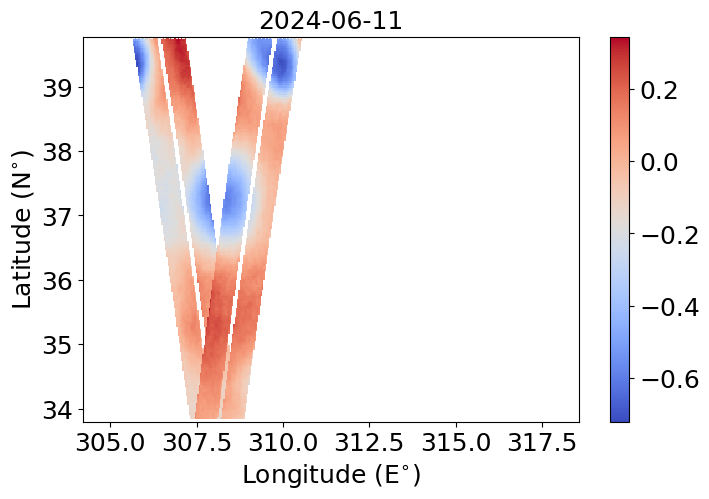

In [27]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh1,cmap='coolwarm')
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh2,cmap='coolwarm')
cbar = plt.colorbar(plot,ax=ax)

# cbar.set_label('dsdx', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

In [28]:
def compute_geos_current(ssh,lat):
    """
    ssh: (m) Make sure this is first corrected with height_cor_xover from L2 data! 
    lat: degrees N
    """
    
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lat*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)
    
    dx,dy = 4000,4000 # m i changed it to 4000 to match res? need to double check
    gravity = 9.81

    dsdy,dsdx=np.array(np.gradient(ssh, dx, edge_order=1))
    vg = (gravity/np.array(f_coriolis))*dsdx
    ug = -(gravity/np.array(f_coriolis))*dsdy
    geos_current = np.sqrt(ug**2 + vg**2)
    
    return ug,vg,geos_current

Compute geostrophic currents

In [29]:
#Calculate
ug1,vg1,geos_current1 = compute_geos_current(grid_ssh1,grid_y)
ug2,vg2,geos_current2 = compute_geos_current(grid_ssh2,grid_y)

<Figure size 640x480 with 0 Axes>

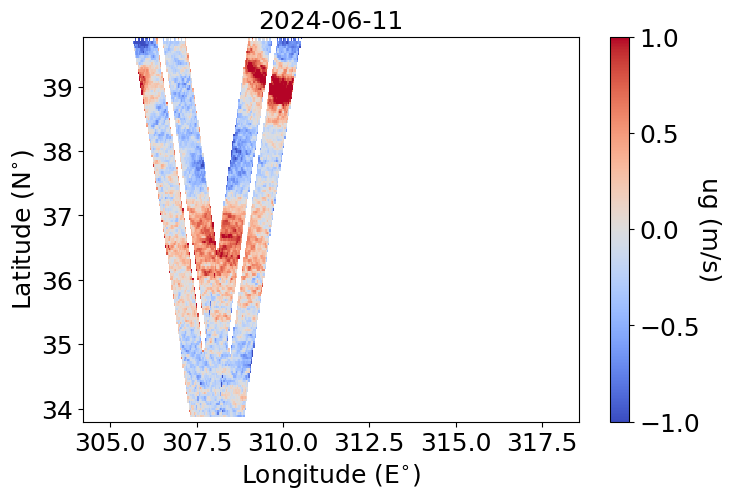

<Figure size 640x480 with 0 Axes>

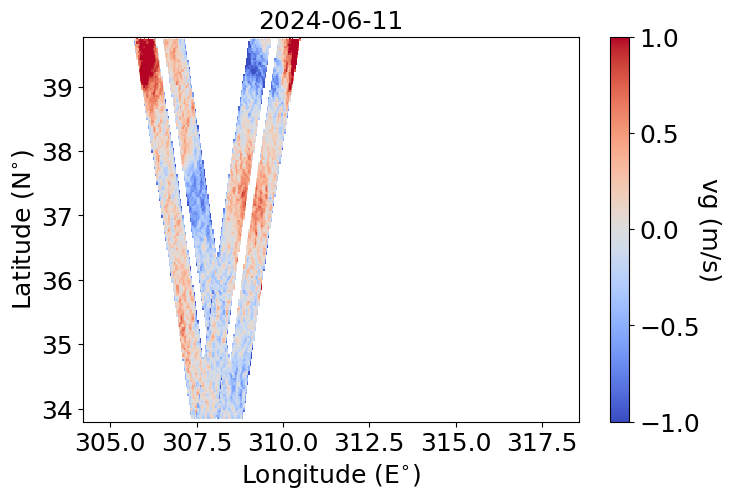

In [30]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,ug1,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,vg1,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(grid_x,grid_y,vg2,cmap='coolwarm',vmin=-1,vmax=1)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

<Figure size 640x480 with 0 Axes>

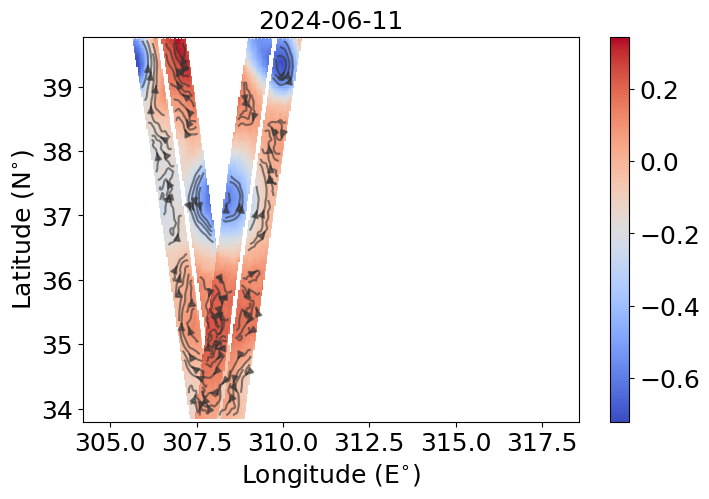

In [34]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh1,cmap='coolwarm')
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh2,cmap='coolwarm')
cbar = plt.colorbar(plot,ax=ax)
plt.streamplot(grid_x,grid_y,ug1,vg1, density = 5, color = (0.2,0.2,0.2,0.6))
plt.streamplot(grid_x,grid_y,ug2,vg2, density = 5, color = (0.2,0.2,0.2,0.6))

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

### Load eddy data from AVISO

Using these contours to plot contour on top of chl & define in versus out of the eddy.

In [38]:
def get_eddy_by_ID_date(ds,eddy_date):
    """
    ds: netCDF AVISO format
    track_id: id of eddy to extract
    eddy_date: date in format 'YYYY-MM-DD'

    Returns contour lons, contour lats, center lon, center lat
    """
    try:
        ind = np.where(ds.time == np.datetime64(eddy_date))[0][0]
        contour_lons = np.array(ds.effective_contour_longitude[ind])
        contour_lats = np.array(ds.effective_contour_latitude[ind])
    except:
        print('No eddy data available with that request ... :(')        
    
    return contour_lons,contour_lats,ds.longitude[ind],ds.latitude[ind]

In [39]:
contour_lons,contour_lats,center_lon,center_lat = get_eddy_by_ID_date(aviso_ds,pacedate)

### Add in low-res altimeter data (OSCAR Velocity)

In [50]:
results = earthaccess.search_datasets(keyword="oscar")
for item in results[:7]: # subsetted to show the first couple of results because this is erroring for some reason
    summary = item.summary()
    print(summary["short-name"])

OSCAR_L4_OC_NRT_V2.0
OSCAR_L4_OC_FINAL_V2.0
OSCAR_L4_OC_INTERIM_V2.0


KeyError: 'FileDistributionInformation'

In [ ]:
bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
results = earthaccess.search_data(
        short_name="OSCAR_L4_OC_INTERIM_V2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
oscar_paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

In [ ]:
dates_available = []
for i in oscar_paths:
    today = str(i).split('.')[-2].split('_')[-1]
    if today not in dates_available:
        dates_available.append(today)
print(dates_available)

In [ ]:
# date_requested = '20240508'

ind = 0 
for i in oscar_paths:
    today = str(i).split('.')[-2].split('_')[-1]
    if date_requested == today:
        print(ind)
    ind += 1

In [ ]:
print(oscar_paths[35])

In [ ]:
oscar_ds = xr.open_dataset(oscar_paths[35])
oscar_ds = oscar_ds.transpose("time", "latitude", "longitude") # oscar reads in stupid, so just do this line.. trust me ;)
oscar_ds

In [ ]:
def crop_oscar_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.lat >= latmin) & (ds.lat <= latmax) & (ds.lon >= lonmin+360) & (ds.lon <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [ ]:
oscar_ds_masked = crop_oscar_by_lat_lon(oscar_ds,latmin,latmax,lonmin,lonmax)
oscar_ds_masked

Each of the layers could be commented out as preferred (as in the presentation)

In [ ]:
plt.clf()

magnitude = 1.5

fig,ax=plt.subplots(figsize=(8,5))

# LOW RES VELOCITY
plot = ax.pcolormesh(oscar_ds_masked.lon-360,oscar_ds_masked.lat,oscar_ds_masked.ug[0],cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# SWOT SWATHS OF VELOCITY
ax.pcolormesh(grid_x-360,grid_y,ug1,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
ax.pcolormesh(grid_x-360,grid_y,ug2,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# STREAMLINES FROM SWOT
ax.streamplot(grid_x_180,grid_y,ug1,vg1, density = 3, color = 'k')
ax.streamplot(grid_x_180,grid_y,ug2,vg2, density = 3, color = 'k')

# EDDY CONTOUR
ax.plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)

# PARAMS 
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))
ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')

ax.set_xlim([lonmin,lonmax])
ax.set_ylim([latmin,latmax ])

plt.show()

In [ ]:
### Now, working with low-res altimeter data

In [ ]:
def dimension_edges(dim_array):
    adjustment = float(dim_array[1]-dim_array[0])/2
    adjusted_array = [float(i)-adjustment for i in dim_array]
    adjusted_array.append(dim_array[-1]+adjustment)
    return np.array(adjusted_array)

In [ ]:
plt.clf()
fig,ax=plt.subplots(figsize=(8,5))

# Low res SLA
magnitude=1 # SLA range (m)

#Need to convert from lat/lon centers to edges to align the plot appropriately (see example above for a different options with lon_bnds/lat_bnds)
CMEMS_lon_edges = dimension_edges(CMEMS_day.longitude)
CMEMS_lat_edges = dimension_edges(CMEMS_day.latitude)
CMEMS_lon_inds = np.where((CMEMS_lon_edges >= lonmin) & (CMEMS_lon_edges <= lonmax))
CMEMS_lat_inds = np.where((CMEMS_lat_edges >= latmin) & (CMEMS_lat_edges <= latmax))

plot = ax.pcolormesh(CMEMS_lon_edges[CMEMS_lon_inds], CMEMS_lat_edges[CMEMS_lat_inds],CMEMS_day.sla[0,CMEMS_lat_inds[0],CMEMS_lon_inds[0]],
                     cmap='coolwarm',vmin=-magnitude,vmax=magnitude,shading='nearest')

#ax.grid(c='k')

# SWOT SSHA; not sure how to adjust this grid appropriately 
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,np.add(ds1_masked.ssha_karin_2,ds1_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)


# STREAMLINES FROM SWOT
ax.streamplot(grid_x_180,grid_y,ug1,vg1, density = 3, color = 'k')
ax.streamplot(grid_x_180,grid_y,ug2,vg2, density = 3, color = 'k')

# EDDY CONTOUR
ax.plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)
#ax.scatter(center_lon-360,center_lat,c='k')


cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

ax.set_xlim([lonmin,lonmax])
ax.set_ylim([latmin,latmax ])

#plt.savefig('Edward_SLA_20240508.png',dpi=350,bbox_inches='tight')
#plt.show()

In [ ]:
fig.clf()
fig,ax=plt.subplots(1,3,figsize=(20,4))

# a) SLA
magnitude=10 # SLA range (m)
plot = ax[0].pcolormesh(CMEMS_lon_edges[CMEMS_lon_inds], CMEMS_lat_edges[CMEMS_lat_inds],CMEMS_day.sla[0,CMEMS_lat_inds[0],CMEMS_lon_inds[0]]*10,
                     cmap='coolwarm',vmin=-magnitude,vmax=magnitude,shading='nearest')


ax[0].pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,np.add(ds1_masked.ssha_karin_2,ds1_masked.height_cor_xover)*10,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
ax[0].pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover)*10,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
cbar = plt.colorbar(plot,ax=ax[0])
cbar.set_label('SLA (cm)', rotation=270, labelpad=20)
ax[0].set_ylabel('Latitude (N$^{\circ}$)')


# b) Pro:Syn 
plot=ax[1].pcolormesh(lon,lat,np.divide(pro,syn),cmap='YlGnBu',vmax=1.25*(10**2))
cbar = plt.colorbar(plot,ax=ax[1])
cbar.set_label('Pro:Syn', rotation=270, labelpad=20)
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
ax[1].set_yticklabels([])

# Pro:Pico
plot=ax[2].pcolormesh(lon,lat,np.divide(pro,pico),cmap='YlGnBu',vmax=3*(10**2))
cbar = plt.colorbar(plot,ax=ax[2])
cbar.set_label('Pro:Pico', rotation=270, labelpad=20)
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
ax[2].set_yticklabels([])

for c in [0,1,2]:
    ax[c].set_ylim([34,38])
    ax[c].set_xlim([-73,-68])
    ax[c].set_facecolor('#e2e2e2')
    ax[c].set_xlabel('Longitude (E$^{\circ}$)')
        
    # STREAMLINES FROM SWOT
    ax[c].streamplot(grid_x_180,grid_y,ug1,vg1, density = 5, color = 'k',linewidth=0.5)
    ax[c].streamplot(grid_x_180,grid_y,ug2,vg2, density = 5, color = 'k',linewidth=0.5)

    # EDDY CONTOUR
    ax[c].plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)
    
ax[0].text(-74,38,'a)')
ax[1].text(-73.5,38,'b)')
ax[2].text(-73.5,38,'c)')

#plt.show()
#plt.savefig('Edward_SLA_MOANA_trio_20240508.png',dpi=350,bbox_inches='tight')

NOTE: I realized we don't have to calculate the "edges" for plotting with pcolormesh, as they're in the lon_bnds and lat_bnds variables

In [ ]:
CMEMS_day.lon_bnds[:,0].values # western edges of pixels

In [ ]:
CMEMS_day.lon_bnds[:,1].values # eastern edges of pixels

In [ ]:
CMEMS_day.lat_bnds[:,0].values[0:10] # northern edges of pixels

In [ ]:
CMEMS_day.lat_bnds[:,1].values[0:10] # southern edges of pixels

### Eddy-centered fig

Defining plot bounds to be centered on the eddy

In [ ]:
print(lonmin)
print(lonmax)
print(latmin)
print(latmax)

In [ ]:
plt.clf()
fig,ax=plt.subplots(figsize=(6.5,5))

# Low res SLA
magnitude=1 # SLA range (m)

# get cropping indices based on the cell centers
CMEMS_lon_inds = list(np.where((CMEMS_day.longitude >= lonmin) & (CMEMS_day.longitude <= lonmax))[0])
CMEMS_lat_inds = list(np.where((CMEMS_day.latitude >= latmin) & (CMEMS_day.latitude <= latmax))[0])

# add last value to be centered based on python indexing
CMEMS_lon_inds.append(CMEMS_lon_inds[-1]+1)
CMEMS_lat_inds.append(CMEMS_lat_inds[-1]+1)

# pcolormesh expects the cell edge coordinates, not the center coords; using the western & northern bounds
plot = ax.pcolormesh(CMEMS_day.lon_bnds[:,0].values[CMEMS_lon_inds[0]:CMEMS_lon_inds[-1]+1], 
                     CMEMS_day.lat_bnds[:,0].values[CMEMS_lat_inds[0]:CMEMS_lat_inds[-1]+1],
                     CMEMS_day.sla[0,CMEMS_lat_inds,CMEMS_lon_inds],
                     cmap='coolwarm',vmin=-magnitude,vmax=magnitude,shading='nearest')
#ax.grid(c='k')

# SWOT SSHA; not sure how to adjust this grid appropriately 
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,np.add(ds1_masked.ssha_karin_2,ds1_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# STREAMLINES FROM SWOT
ax.streamplot(grid_x_180,grid_y,ug1,vg1, density = 5, color = 'k',linewidth=0.5)
ax.streamplot(grid_x_180,grid_y,ug2,vg2, density = 5, color = 'k',linewidth=0.5)

# EDDY CONTOUR
ax.plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)
ax.scatter(center_lon-360,center_lat,c='k')

cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
#ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

ax.set_xlim([lonmin,lonmax])
ax.set_ylim([latmin,latmax])

#plt.savefig('Edward_SLA_20240508_low_res_gridded.png',dpi=350,bbox_inches='tight')
#plt.savefig('Edward_SLA_20240508_high_res_overlay.png',dpi=350,bbox_inches='tight')